# AES Trace Generation and DPA

You are given a set of power traces taken during
AES-ECB executions (extracted via simulation VCD dump) with the associated input/output values of AES, and
you are asked to extract the 128-bit secret key via Differential Power Analysis
(DPA).

---

## 1 Download provided files

Gdown is a package to download Google Drive Folders. All our required AES files are on google drive, and this will be used to pull in the required files.

### 1.1 Install gdown package

In [ ]:
!pip install gdown

### 1.2 Download the files from google drive using gdown

The google drive folder, which we are going to download using gdown, is [here](https://drive.google.com/drive/folders/1pPd6e4pJM7x8eoPraKG3YzYTP1fGCtPO).

In [ ]:
import gdown
gdown.download_folder(id='1pPd6e4pJM7x8eoPraKG3YzYTP1fGCtPO', quiet=False, use_cookies=False)

---

## 2 Directory Structure

The downloaded files will show up under the `FILES` tab on the left side (see image below). The directory structure and the individual files (before running any simulation) are explained below.

Directory Structure:

```
> DPA_AES
  > rtl
  > scripts
  > sim
```

- ```DPA_AES``` is the parent folder, which contains 3 sub-folders.
  - ```rtl```
    - This subfolder contains the Verilog RTL model of AES-128 (```aes128_table_ecb.sv```).
  - ```scripts```
    - This contains a Bash script to extract all the registers in the simulation VCD file.
    - The extracted registers and their values are then used to generate the power trace using Hamming Distance.
  - ```sim```
    - This subfolder contains the plaintext and ciphertext raw files. These are in ```plaintext_ciphertext_orig_5000.txt``` (which contains `5000` plaintext and cipher text combinations), and ```plaintext_ciphertext_orig_10000.txt``` (which contains `10000` plaintext and cipher text combinations).
    - Two sets are provided as running `10000` plaintext-cipthertext through your simulation might take long. Not all attacks are guaranteed to require 10000 traces to extract the secret key. If you can achive it with fewer traces, then you will save time by running a shorter simulation.
    - This subfolder also contains the testbench for the AES-128 RTL (```tb_aes128_table_ecb_5k.sv``` and ```tb_aes128_table_ecb_10k.sv```).
      - Functionally, these are almost identical. ```_5k``` testbench is for running `5000` plaintext-ciphertext simulation, and ```_10k``` testbench is for running `10000` plaintext-ciphertext simulation.
      - Depending on where you perform the DPA attack, you might either need 5K traces or 10K traces.



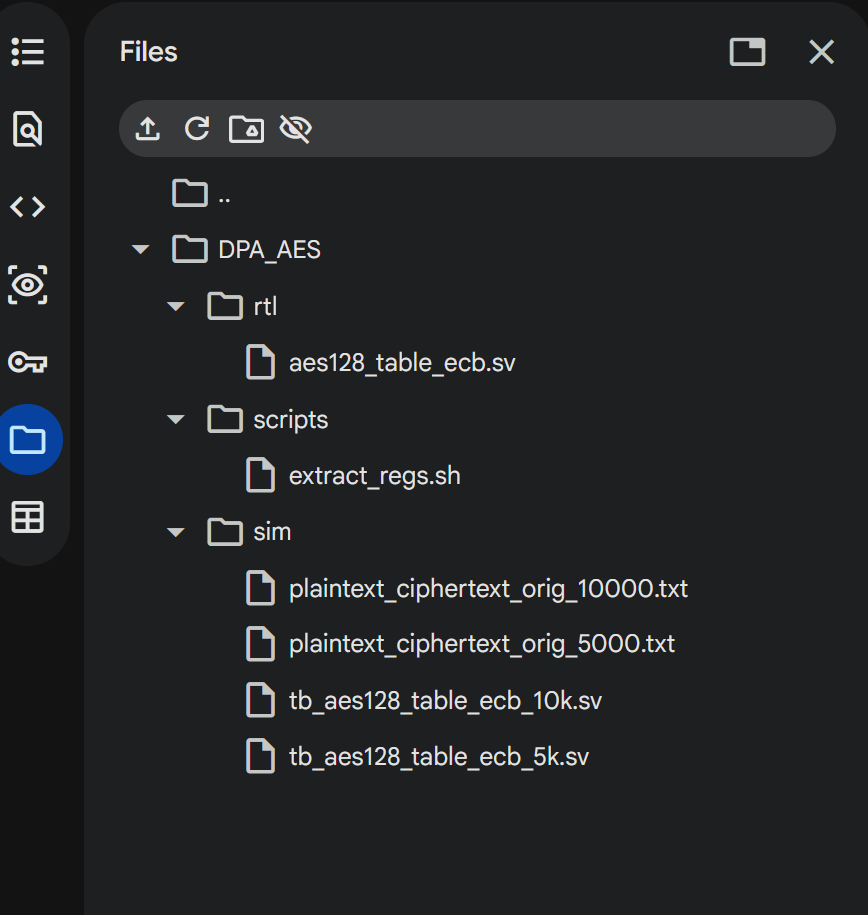

---

## 3 Power Trace Generation

### 3.1 iVerilog: A Verilog Simulator

iVerilog is an open-source Verilog simulator that allows you to simulate and test your hardware designs written in the Verilog Hardware Description Language (HDL). It's a valuable tool for verifying the functionality of your circuits before physical implementation.

**Key Features:**

* **Open-source:**  Freely available and modifiable.
* **Verilog Support:** Supports various Verilog standards, including SystemVerilog.
* **Simulation Capabilities:** Enables functional simulation of digital circuits.
* **Debugging:** Provides debugging tools to identify and fix errors in your designs.

**Common Use Cases:**

* **Verification:**  Test your HDL code for correctness and functionality.
* **Prototyping:**  Simulate hardware designs before implementing them in hardware.
* **Education:**  Learn and practice Verilog coding and simulation.

First, we install iVerilog, select our design and testbench verilog files, then run iVerilog simulation with those. In our case, the design file is AES implementation and the testbench is custom designed one to run AES with a set of plaintexts to generate the output ciphertexts.

#### 3.1.1 Install iVerilog

In [ ]:
!apt update && apt install -y iverilog

#### 3.1.2 Simulation Commands

We first setup the input files and then call the iverlog simulation command.

##### 3.1.2.1 Select simulation input files

Here we select the simulation files.


*   RTL Design File (AES): ```aes128_table_ecb.sv```
*   Testbench File (for 5k simulations): ```tb_aes128_table_ecb_5k.sv```

5k simulations means 5000 plaintext-cipthertexts are simulated through AES. If you want to run 10000 plaintext-cipthertext simulation, replace ```SIM_File = "DPA_AES/sim/tb_aes128_table_ecb_5k.sv"``` with ```SIM_File = "DPA_AES/sim/tb_aes128_table_ecb_10k.sv"```


In [ ]:
RTL_File = "DPA_AES/rtl/aes128_table_ecb.sv"
SIM_File = "DPA_AES/sim/tb_aes128_table_ecb_5k.sv"

##### 3.1.2.2 Run iVerilog simulation

-o : output file,
-g : verilog version

Please note that the simulation takes minutes. `_5k` sim takes around 6 minutes, `_10k` sim around 12 minutes.

This creates 3 outputs,

*   `aes.out`
*   `output.txt`
*   `waveform.vcd`

These outputs, by default, are created in the parent directory, which sits above the `DPA_AES` directory. If you want to save time with simulation (if you need to stop at some point and come back), I would suggest downloading these files, saving them on your computer, and then reuploading them back to Google Colab when you next start working on it again.

You can upload into your Google Colab session by selecting the `Files` tab on the left side, and there will be an Upload Icon on the top (the image under Section 2 has that icon, just above the `DPA_AES` folder, to the left of the Refresh Icon).

Of these files, we're most interested in the VCD file, `waveform.vcd`. This is explained in detail in the next section.

In [ ]:
!iverilog -g2012 -o aes.out $RTL_File $SIM_File
!vvp aes.out > output.txt

### 3.2 VCD Parsing

VCD is a Value Change Dump file. Generally, outputs of RTL simulations are stored as VCD files (dumped from the testbench). This records the starting value of all wires and registers, and all the subsequent changes in their values over the entire simulation duration. VCD files generally record these changes at half clock periods (both edges of a clock). If a value does not change, it is not recorded after the initial value.

We plan to use this VCD file to extract the register values (D-flipflops) from this file and use that to estimate the power trace.

#### 3.2.1 Run the regex script to extract registers from VCD File

The script ```extract_regs.sh```, as the name suggests, extracts the register names from the VCD file. We use regular expressions to find registers in the VCD, extract their names, and then store them into an output file.



Set the input script file, VCD file, and the output register file.

In [ ]:
Regex_File = "DPA_AES/scripts/extract_regs.sh" # Script
VCD_File = "waveform.vcd" # VCD
Filtered_Reg_File = "register_file.txt" # Output register file

Run the Bash script.

In [ ]:
#Convert the regex script to be executable
!chmod +x $Regex_File

#Extract Registers based on "reg field" in the vcd file and store in a text file
"""
  Script: extract_regs.sh
  Input File: waveform.vcd
  Output File: register_file.txt
"""
!$Regex_File $VCD_File $Filtered_Reg_File

#### 3.2.2 Import Register Names

Now we will import the extracted register names (from the VCD file using the Bash script) into our Python environment.

We will first define the function `extract_register_names` that can read the .txt file and extract the names, and then invoke it.

At the end, `register_list` will contain the list of all extracted registers in our environment.

In [ ]:
import re

# Define extract_register_names

def extract_register_names(filename="register_file.txt"):
    """
      Input: register_file.txt
      Output: list of register names
      Description: Extracts each word in the file and adds it to a list
    """
    register_names = []
    try:
        with open(filename, 'r') as file:
            for line in file:
                match = re.search(r"\b(\w+)\b", line) # Matches any whole word

                if match:
                    register_name = match.group(1)
                    register_names.append(register_name)
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    return register_names

In [ ]:
# Invoke extract_register_names

register_list = extract_register_names(Filtered_Reg_File)

#### 3.2.3 Extracting Register VCD

Now, we will use the VCD file to extract the values of the registers as they change during the course of the simulation. This will let us use a Hamming Weight model to then estimate the power consumption of those registers.

We will install the required packages `matplotlib.pyplot` and `vcdvcd`

`matplotlib.pyplot` is a state-based collection of functions in the Matplotlib library that provides a MATLAB-like interface for creating visualizations in Python. It is the de-facto standard for 2D plotting in data science and engineering.

* **Primary Use Case:** Creating static, interactive, and animated plots (such as line graphs, scatter plots, histograms, and bar charts) to visualize data.
* **How it Works in Colab:** You pass numerical data (like lists or pandas DataFrames) to its plotting functions, customize aesthetic elements like labels, titles, and colors, and then render the visualization directly inline within your notebook cells.

`vcdvcd` is a Python library utilized to parse and analyze **Value Change Dump (VCD)** files. VCD is an industry-standard, text-based file format generated by Electronic Design Automation (EDA) tools (like Verilog or VHDL simulators) that logs the changes in digital signal values over time during hardware simulation.

* **Primary Use Case:** Extracting waveform and signal transition data from digital circuit simulations so it can be verified, analyzed programmatically in Python, or plotted (often by passing the extracted timing data into `matplotlib`).
* **How it Works:** The package reads the VCD file structure, parses the hierarchical variable definitions, and maps out the exact timestamps and logical value transitions (like 0, 1, x, or z) for specified hardware signals.

In [ ]:
!pip install vcdvcd matplotlib

Import the installed packages

In [ ]:
import matplotlib.pyplot as plt
from vcdvcd import VCDVCD

Parse the vcd file using VCDVCD. We will get all the signals listed in the vcd file, compare against our set of extracted registers. We do this using `find_matching_signals`.

In [ ]:
# Load the VCD file
vcd = VCDVCD(VCD_File)

# Extract available signals
signals = list(vcd.signals)

In [ ]:
# Define find_matching_signals to find signals with any value from register_list in their name
def find_matching_signals(signals, register_list):
    """
      Input: signals
             register_list
      Output: list of matching signals
      Description: Finds signals with any value from register_list in their name
    """
    matching_signals = []
    for signal in signals:
        for register in register_list:
            if register in signal:
                #Skipping custom signals used as counters
                if "tb_aes128_table_ecb.dut.itemp" not in signal and "tb_aes128_table_ecb.dut.temp" not in signal:
                  matching_signals.append(signal)
                break # Avoid adding the same signal multiple times if multiple registers match
    return matching_signals

Invoke `find_matching_signals`, with the list stored as `matching_signals`. This list is the exact path to the signal in the VCD (including any modules and submodules it is instantiated in), and its size.

In [ ]:
matching_signals = find_matching_signals(signals, register_list)

Creating text file with this `matching_signals` data. The reason we do this is so that you can save this file and not have to run this multiple times. Maybe this was not throught out as well.

In [ ]:
# Dump matching_signals to a text file
with open("matching_signals.txt", "w") as f:
    for signal in matching_signals:
        f.write(signal + "\n")

### 3.3 Hamming Distance Multi-Trace Generation

Hamming Distance Power Model

In [ ]:
def compute(prev_value,current_value,HD=True):
    """
      Input: prev_value
              current_value
              hw
      Output: hamming_diff
      Description: Computes the hamming distance between two integers (if HD)
                    or returns the hamming weight value (if not HD)
    """
    diff = 0
    if HD:
      diff = prev_value ^ current_value
    else:
      diff = current_value

    hamming_diff = diff.bit_count()

    return hamming_diff

Compute Power for each Register

In [ ]:
import numpy as np
from collections import defaultdict

# Dictionary to store the Hamming distance traces for each signal
hamming_diff_traces = {}

# List to store total Hamming distance traces (each entry is a separate trace)
total_hamming_diff_traces = []

# Iterate through matching signals
for signal in matching_signals:
    signal_values = vcd[signal].tv  # Extract signal values over time
    traces = []          # List to store split traces for this signal
    current_trace = []   # Current trace segment
    prev_value = None    # Previous integer value for computing Hamming distance

    for t, v in signal_values:
        # Note: 'x' occurs at dumpoff, so split trace on encountering 'x'
        if 'x' in str(v):
            if current_trace:  # Save the current trace if it has data
                traces.append(current_trace)
                current_trace = []  # Reset for a new trace
            prev_value = None  # Reset previous value for a new trace segment
        else:
            # Convert value to integer
            int_value = int(v,2)
            if prev_value is None:
                # First value in a trace: no previous value so distance is 0
                hamming_diff = 0
            else:
                # Compute Hamming distance as the number of differing bits
                hamming_diff = compute(prev_value, int_value, True)

            prev_value = int_value  # Update previous value

            # Append the (time, Hamming distance) to the current trace
            current_trace.append((t, hamming_diff))

    # Save the last trace if it has data
    if current_trace:
        traces.append(current_trace)

    # Store traces for the current signal
    hamming_diff_traces[signal] = traces

Combine (sum) individual signals into global total traces

In [ ]:
# Determine the maximum number of trace segments across all signals.
max_traces = max(len(traces) for traces in hamming_diff_traces.values())

# Create a list of global total traces.
# Each element is a defaultdict (keyed by timestamp) that will accumulate Hamming distances.
total_hamming_diff_traces = [defaultdict(int) for _ in range(max_traces)]

# For each signal, add its trace segment values to the corresponding global trace.
for signal, traces in hamming_diff_traces.items():
    for i, trace in enumerate(traces):
        for t, diff in trace:
            total_hamming_diff_traces[i][t] += diff

# Convert each global trace dictionary into sorted lists for plotting.
global_traces = []
for trace_dict in total_hamming_diff_traces:
    sorted_timestamps = sorted(trace_dict.keys())
    sorted_diffs = [trace_dict[t] for t in sorted_timestamps]
    global_traces.append((sorted_timestamps, sorted_diffs))

### 3.4 Interpolating Generated Trace

UnivariateSpline

In [ ]:
from scipy.interpolate import UnivariateSpline
# List to store interpolated global traces
# Each element is a tuple: (new_timestamps, new_diffs)
interpolated_global_traces = []

# Iterate over all traces in global_traces to interpolate them
for timestamps, diffs in global_traces[0:-1]:
    # Set a smoothing factor based on variance and number of points (adjust as needed)
    smoothing_factor = 0.1 * np.var(diffs) * len(timestamps)

    # Create the smoothing spline for the current trace
    spline = UnivariateSpline(timestamps, diffs, s=smoothing_factor)

    # Create a new, evenly spaced time axis for interpolation (e.g., 1000 points)
    new_timestamps = np.linspace(min(timestamps), max(timestamps), 1000)
    new_diffs = spline(new_timestamps)

    # Store the interpolated results
    interpolated_global_traces.append((new_timestamps, new_diffs))

Dumping interpolated traces as a CSV

In [ ]:
Trace_File = "interpolated_traces_no_timestamps.csv"

In [ ]:
import csv

# Prepare data for CSV
csv_data = []
for timestamps, diffs in interpolated_global_traces:
    csv_data.append(diffs)  # Only diffs as no timestamps required

# Write to CSV
with open(Trace_File, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(csv_data)


### 3.5 Observing Hamming Distance of a signal

Choose the Signal you would like to plot! \
Tip: matching_signals.txt has the names of sigals you would be interested in


In [ ]:
signal_to_plot = 'tb_aes128_table_ecb.clk_reg'

Plotting Hamming Distance of Chosen Signal

In [ ]:
times, weights = zip(*hamming_diff_traces[signal_to_plot][0])
plt.figure(figsize=(20, 6))
plt.step(times, weights)
plt.xlabel("Time")
plt.ylabel("Hamming distance")
plt.title(f"Hamming distance Trace of signal {signal_to_plot}")
plt.grid(True)
plt.show()

---

## 4 DPA

### 4.1 Importing Power Trace

In [ ]:
import pandas as pd
df = pd.read_csv(Trace_File,header=None)

### 4.2 Importing CipherText and PlainText

lines is a list containing plaintext values

lines2 is a list containing ciphertext values.

In [ ]:
lines = []
lines2 = []
with open('DPA_AES/sim/plaintext_ciphertext_orig_5000.txt', 'r') as f:
    for line in f:
        plaintext, ciphertext = line.strip().split('_')
        lines.append(plaintext)
        lines2.append(ciphertext)

### 4.3 Trace Overview

Waveform for 1 AES Encryption

It is essential to note that the Verilog code for each AES encryption behaves in a predictable manner.


1.   It first starts with a Reset phase `Reset Asserted` in the figure.
2.   Round-0 (the first red box from the left side) occurs during the Key Expansion phase, as the Key for Round-0 is the secret key, but for future rounds, you need a transformed version of the secret key.
3.   Only after the full Key Expansion is complete does Round-1 start (2nd red box from the left), followed by all other rounds consecutively (red boxes), one per clock cycle.
4.   Ideally, you want to analyze the trace during the blue arrow, as the includes all the rounds of AES. It does, however, also include Key Expansion (during Round-0), so keep that in mind.



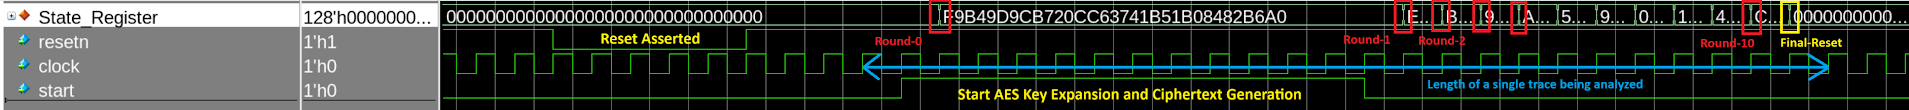

Note: Right click on the image and open in new tab for a larger view

### 4.4 Assignment

#### 4.4.1 Task 1 - Analyzing the power trace


##### 4.4.1.1 Subtask A

Plot the first power trace (Figure 1), corresponding to the first encryption operation.

##### 4.4.1.2 Subtask B

**Question 1.** Analyze the power trace you plotted in Task 1 (Figure 1). What are the peaks in the trace? How is AES implemented?

Hint: Compare the trace against the waveform above to see what the peaks correspond to.

##### 4.4.1.3 Subtask C

Before we proceed to DPA, think of a good pre-processing step to make the attack more successful.

Hint: Plot the first few
power traces and think how to better align them.

#### 4.4.2 Task 2 - Performing the DPA attack



##### 4.4.2.1 Subtask A

Let's execute the DPA attack using Pearson's correlation test. First, think of an easy target operation for the DPA and, second, consider the number of bits to be estimated by DPA at a time.

##### 4.4.2.2 Subtask B

**Question 2.** What is a good power model for the target operation? Justify it.

Note: Feel free to use either Hamming Weight or Hamming Distance before you commit to one.

Change the call to compute function accordingly in section 3.3

##### 4.4.2.3 Subtask C

Apply the DPA on the first byte of the key, plot the results (Figure 2) for all key guesses.

##### 4.4.2.4 Subtask D

Find the maximum correlation (consider both positive and negative peaks) and plot the two best key guesses (Figure 3) that have the maximum likelihood.

##### 4.4.2.5 Subtask E

**Question 3.** Considering the two cases from above (4.4.2.4) , which one is more likely to be the correct key guess? Why do you specifically see these two results?

##### 4.4.2.6 Subtask F

**Question 4.** What is the maximum leak point? Since you are working with an interpolated power trace, a sample number would work.

Plot the ”evolution” of all key hypothesis for 10000 measurements at this particular time instance (Figure 4).

##### 4.4.2.7 Subtask G

**Question 5.** Starting at how many traces, does the key guess with maximum correlation show highest correlation?

##### 4.4.2.8 Subtask H

**Question 6.** Apply the DPA on the entire key. **What is the 128-bit AES
secret key?**

Note that not all key values can be 100% detected depending on your targeted computation, i.e. there can be false positives. If this is the case, you may need to take the first n possible results and apply a brute-force search within these reduced search space.

Hint: Targeting the initialization may
especially cause this behavior, targeting computations after the initialization might be a better idea. You can also try the partition-based tests (with difference of means) to extract the key.

#### 4.4.3 Task 3 - Evaluating the DPA attack



##### 4.4.3.1 Subtask A

**Question 7.** What is the mean time to disclosure, i.e. average number of traces required to extract the key for your DPA attack? To find this average, you need to estimate starting at how many measurement the targeted secret key portion leaks and average this value for all parts. If the key cannot be correctly estimated for a particular key part, you can use the maximum number of measurements (i.e. 10000) for that part.

##### 4.4.3.2 Subtask B

**Question 8.** Compare this with the theoretical cryptanalysis (i.e. brute-force attack) of AES, what is the reduction ratio in the number of traces required to break AES? Why is DPA so powerful?

##### 4.4.3.3 Subtask C

**Question 9 (Bonus).** How long did it take for you to complete questions 1 to 8?